# Garden exploration

Open the SQLite directly, pull tables into pandas, plot. The CLI and this notebook read the same database — no separate export step.

Run from the repo root:

```bash
uv sync --group notebook
uv run jupyter lab
```

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

# point at your instance (the same path the CLI uses)
DB = Path("./garden-data/garden.sqlite").resolve()
assert DB.exists(), f"no DB at {DB} — run `garden init` from repo root first"
engine = create_engine(f"sqlite:///{DB}")

## What's in there

In [2]:
pd.read_sql("SELECT * FROM garden", engine)

,id,name,default_lat,default_lon,timezone
0,1,66 Maple,42.373608,-71.103379,America/New_York


In [3]:
pd.read_sql("SELECT id, name, kind, lat, lon FROM locations", engine)

,id,name,kind,lat,lon
0,patio-bed,patio-bed,raised_bed,42.373608,-71.103379
1,three-flower-pots,three-flower-pots,flower_pot,42.373608,-71.103379
2,seed-tray,seed-tray,seed_tray,42.373608,-71.103379


In [4]:
plants = pd.read_sql(
    """
    SELECT p.id, t.common_name, t.cultivar, p.location_id, p.status, p.planted_at
    FROM plants p LEFT JOIN taxa t ON p.taxon_id = t.id
    """,
    engine,
)
plants

,id,common_name,cultivar,location_id,status,planted_at
0,tomato-improved-garden-gem-1,Tomato,Improved Garden Gem,patio-bed,transplanted,2026-03-04 00:00:00.000000
1,tomato-improved-garden-ruby-1,Tomato,Improved Garden Ruby,patio-bed,transplanted,2026-03-04 00:00:00.000000
2,tomato-improved-bw-hybrid-1,Tomato,Improved BW Hybrid,patio-bed,transplanted,2026-03-04 00:00:00.000000
3,tomato-improved-garden-gem-2,Tomato,Improved Garden Gem,seed-tray,seeded,2026-03-04 00:00:00.000000
4,tomato-improved-garden-ruby-2,Tomato,Improved Garden Ruby,seed-tray,seeded,2026-03-04 00:00:00.000000
5,tomato-improved-bw-hybrid-2,Tomato,Improved BW Hybrid,seed-tray,seeded,2026-03-04 00:00:00.000000
6,tomato-improved-garden-gem-3,Tomato,Improved Garden Gem,seed-tray,seeded,2026-03-04 00:00:00.000000
7,tomato-improved-garden-ruby-3,Tomato,Improved Garden Ruby,seed-tray,seeded,2026-03-04 00:00:00.000000
8,tomato-improved-bw-hybrid-3,Tomato,Improved BW Hybrid,seed-tray,seeded,2026-03-04 00:00:00.000000
9,basil-1,Basil,NaN,three-flower-pots,transplanted,2026-03-04 00:00:00.000000


## Events as a DataFrame

In [5]:
events = pd.read_sql(
    "SELECT id, type, occurred_at, plant_id, location_id, details, notes FROM events ORDER BY occurred_at DESC",
    engine,
    parse_dates=["occurred_at"],
)
events.head(20)

,id,type,occurred_at,plant_id,location_id,details,notes
0,0a138696-4fd4-46a6-b237-baaa76604fb2,amended,2026-05-21,NaN,three-flower-pots,"{""type"": ""cow_manure"", ""quantity"": 0.25, ""unit...",None
1,085becdc-82c1-4cce-bbe4-d1be8fda4546,amended,2026-05-21,NaN,patio-bed,"{""type"": ""cow_manure"", ""quantity"": 0.75, ""unit...",None
2,46304801-8511-4d31-b838-df22ab6bf7f8,transplanted,2026-05-21,basil-8,three-flower-pots,{},None
3,2d409126-15dc-4cdd-a8f5-a573d7f2977e,transplanted,2026-05-21,basil-7,three-flower-pots,{},None
4,5d66d523-fc7c-486c-9ce7-4d5cb1dabbc3,transplanted,2026-05-21,basil-6,three-flower-pots,{},None
5,48e87f26-dfba-4560-a96e-f78794ceeed7,transplanted,2026-05-21,basil-5,three-flower-pots,{},None
6,5daae255-0dcc-46c4-9dce-be0170ff13c1,transplanted,2026-05-21,basil-4,three-flower-pots,{},None
7,8c5a7ef3-97ca-4775-940d-2d1ee6e35594,transplanted,2026-05-21,basil-3,three-flower-pots,{},None
8,0f5378fa-148d-4633-b432-fc375a84b07d,transplanted,2026-05-21,basil-2,three-flower-pots,{},None
9,46f987ad-e5c2-49ec-9edf-e2da74c03436,transplanted,2026-05-21,basil-1,three-flower-pots,{},None


## Weather observations

Run `garden weather` first to populate these.

In [6]:
obs = pd.read_sql(
    """
    SELECT metric, value_numeric, unit, occurred_at, location_id, source
    FROM observations
    WHERE source LIKE 'provider:%'
    ORDER BY occurred_at
    """,
    engine,
    parse_dates=["occurred_at"],
)
obs

,metric,value_numeric,unit,occurred_at,location_id,source
0,rain_mm,0.000000,mm,2026-05-12,patio-bed,provider:open-meteo
1,temp_c_mean,12.200000,C,2026-05-12,patio-bed,provider:open-meteo
2,temp_c_min,7.000000,C,2026-05-12,patio-bed,provider:open-meteo
3,temp_c_max,17.400000,C,2026-05-12,patio-bed,provider:open-meteo
4,sunshine_hours,13.571736,h,2026-05-12,patio-bed,provider:open-meteo
...,...,...,...,...,...,...
322,rain_mm,0.000000,mm,2026-06-02,seed-tray,provider:open-meteo
323,temp_c_mean,15.000000,C,2026-06-02,seed-tray,provider:open-meteo
324,temp_c_min,7.500000,C,2026-06-02,seed-tray,provider:open-meteo
325,temp_c_max,21.900000,C,2026-06-02,seed-tray,provider:open-meteo


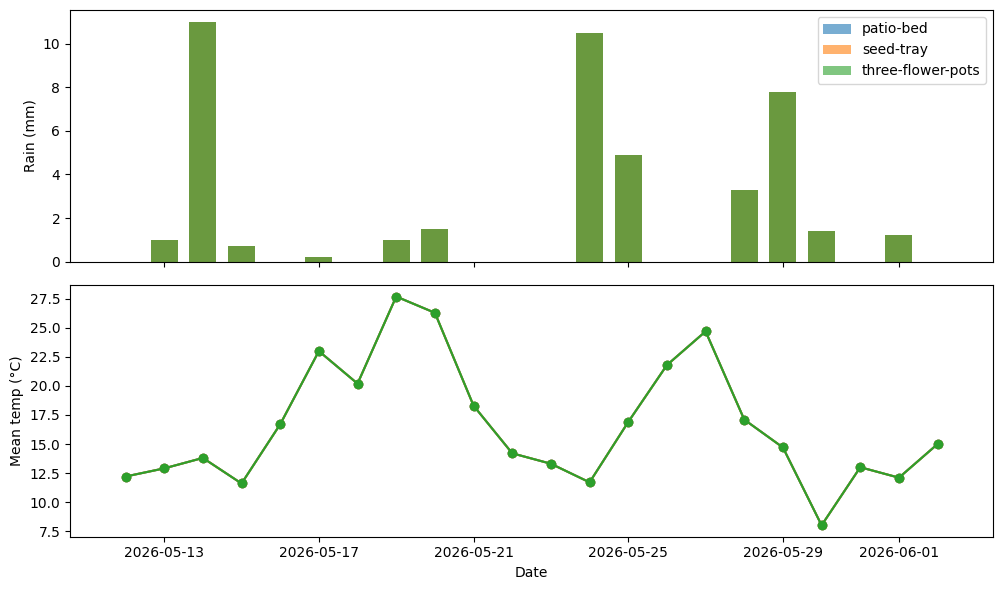

In [7]:
# Plot rain + temperature for each bed.
if not obs.empty:
    fig, (ax_rain, ax_temp) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
    for bed, sub in obs.groupby("location_id"):
        rain = sub[sub.metric == "rain_mm"]
        temp = sub[sub.metric == "temp_c_mean"]
        if not rain.empty:
            ax_rain.bar(rain.occurred_at, rain.value_numeric, width=0.7, alpha=0.6, label=bed)
        if not temp.empty:
            ax_temp.plot(temp.occurred_at, temp.value_numeric, marker="o", label=bed)
    ax_rain.set_ylabel("Rain (mm)")
    ax_temp.set_ylabel("Mean temp (°C)")
    ax_temp.set_xlabel("Date")
    ax_rain.legend()
    plt.tight_layout()
else:
    print("No weather rows yet. Run `garden weather` from the repo root.")

In [ ]:
# TODO: cummulative GDD, cumulative rain, grid of events + recommendations, weather history and forecast

## Cheat-sheet: useful queries

- `SELECT * FROM events WHERE plant_id = 'tomato-garden-gem-1'` — full history of one plant
- `SELECT * FROM events WHERE location_id = 'patio-north' AND type = 'amended'` — soil amendments
- `SELECT SUM(json_extract(details, '$.weight_g')) FROM events WHERE type = 'harvested' AND plant_id = ?` — total harvested weight (SQLite JSON1)
- `SELECT * FROM recommendations WHERE dismissed_at IS NULL` — active recommendations

All tables are documented in `src/garden/storage/models.py`.